In [157]:
import numpy as np
import pandas as pd
from patsy import dmatrices
from sklearn import metrics
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Z treści przed punktami

In [158]:
df = pd.read_csv("Auto.csv")
df['origin'] = df['origin'].astype('category')
df.head(n=5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Tworzenie funkcji pod zadanie a)

Funkcja ta tworzzy i wytrenowuje model


In [159]:
def linearRegression(model_formula, train, valid, print_result=False):      
      
    y_train, X_train = dmatrices(model_formula, data=train, return_type='dataframe')   
    y_valid, X_valid = dmatrices(model_formula, data=valid, return_type='dataframe')

    model = sm.OLS(y_train, X_train) 
    result = model.fit() 

    y_train_pred = result.predict(X_train)
    y_valid_pred = result.predict(X_valid)

    mse_train = metrics.mean_squared_error(y_train, y_train_pred)
    mse_test = metrics.mean_squared_error(y_valid, y_valid_pred)

    if print_result: 
        print(f"Model: {model_formula}")
        print(f"MSE Train: {mse_train:.3f}")
        print(f"MSE Test: {mse_test:.3f}")
        print()

    return result

Dzielenie modelu na częśc testową i na część treningową<br>

do tego wywoływanie funkcji i wypisywanie modelu

- Przedziały ufności: zakres wartości, w którym z dużym prawdopodobieństwem znajduje się prawdziwy parametr (np. współczynnik regresji).
- p-values: prawdopodobieństwo, że dany efekt występuje przypadkowo; im mniejsze, tym bardziej istotny statystycznie.
- T-statistic: testuje, czy współczynnik różni się istotnie od zera.
- F-statistic: testuje, czy cały model jest istotny (czy predyktory wyjaśniają zmienność).
- R²: procent zmienności zmiennej objaśnianej wyjaśniony przez model (0–1).

In [160]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])
df = df.drop(columns=['name'])

train, valid = train_test_split(df, test_size=0.2, random_state=37)

linearRegression('mpg ~ horsepower', train, valid, True).summary()

Model: mpg ~ horsepower
MSE Train: 23.035
MSE Test: 27.617



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     484.6
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           2.14e-65
Time:                        17:16:52   Log-Likelihood:                -935.07
No. Observations:                 313   AIC:                             1874.
Df Residuals:                     311   BIC:                             1882.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.6692      0.789     50.259      0.000      38.116      41.222
horsepower    -0.1563      0.007    -22.013      0.000      -0.170      -0.142
==============================================================================
Omnibus:                       14.311   Durbin-Watson:                   2.051
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.058
Skew:                           0.529   Prob(JB):                     0.000537
Kurtosis:                       3.184   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Zadanie b)
correlation matrix
scatter matrix

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceleration      1.000000  0.290316  0.212746  

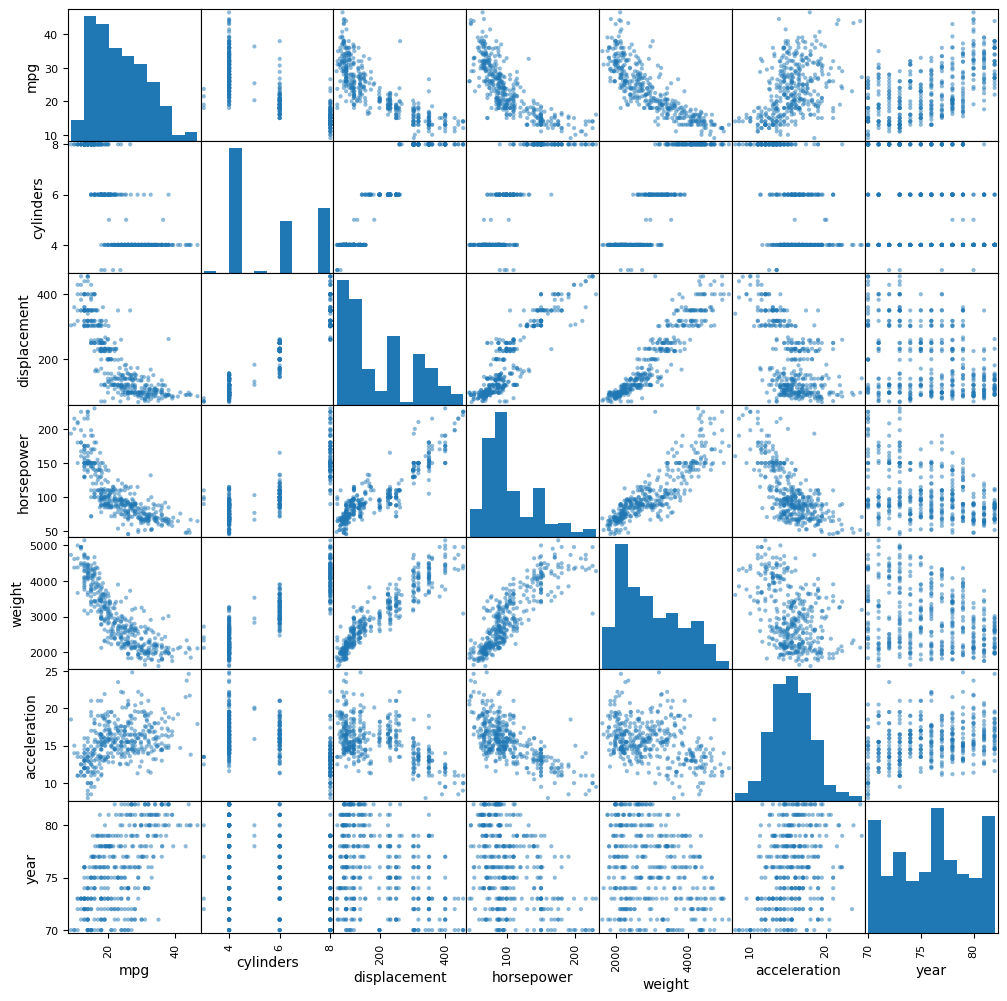

In [161]:
print(df.corr())
axis = pd.plotting.scatter_matrix(df, figsize=(12,12))

Zadaeni c)

Definowanie modeli

- Błąd generalizacji: różnica między skutecznością modelu na danych treningowych a walidacyjnych; im mniejszy, tym lepiej model działa na nowych danych.


In [162]:
models = [
    'mpg ~ cylinders',
    'mpg ~ displacement',
    'mpg ~ horsepower',
    'mpg ~ weight',
    'mpg ~ acceleration',
    'mpg ~ year',

    'mpg ~ horsepower + weight',
    'mpg ~ horsepower + weight + year',
    'mpg ~ displacement + weight + year',
    'mpg ~ cylinders + horsepower + weight',
    'mpg ~ cylinders + horsepower + weight + acceleration + year',

    'mpg ~ horsepower + I(horsepower**2)',
    'mpg ~ weight + I(weight**2)',
    'mpg ~ displacement + I(displacement**2)',
    'mpg ~ I(np.log(weight))',
    'mpg ~ I(np.log(horsepower))',

    'mpg ~ horsepower * weight',
    'mpg ~ horsepower * year',
    'mpg ~ weight * year',
    'mpg ~ cylinders * weight',
    'mpg ~ horsepower * acceleration',

    'mpg ~ I(np.log(weight)) * year',
    'mpg ~ horsepower + I(horsepower**2) + weight',
    'mpg ~ horsepower * I(weight**2)',
    'mpg ~ I(np.sqrt(horsepower)) * weight',

    'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year',

    'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + I(horsepower**2) + I(weight**2) + I(year**2)'
]

Funckja do obliczania błędu genralizacji

In [163]:
def compute_rmse(model, val_df, formula=None, X_cols=None):
    if formula is not None:
        # używamy patsy do przygotowania design matrices
        y_val, X_val = dmatrices(formula, data=val_df, return_type='dataframe')
        preds = model.predict(X_val)
        y_true = np.asarray(y_val).ravel()
    elif X_cols is not None:
        X_val = val_df[X_cols]
        X_val = sm.add_constant(X_val, has_constant='add')
        preds = model.predict(X_val)
        y_true = val_df['mpg'].values
    else:
        raise ValueError("Podaj formula lub X_cols")
    rmse = np.sqrt(metrics.mean_squared_error(y_true, preds))
    return rmse

Towrzenie modeli z ich definicji

In [164]:
results = []
rmse_list = []

for model in models:
    result = linearRegression(model, train, valid)
    rmse = compute_rmse(result, valid, formula=model)
    results.append(result)
    rmse_list.append(rmse)

Wypisywanie najlepszego modelu:

In [165]:
min_model = min(zip(models, rmse_list), key=lambda x: x[1])
print(f"Best genralization error:\n\tmodel: {min_model[0]}\n\tgeneralization error: {min_model[1]:.5f}")

Best genralization error:
	model: mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + I(horsepower**2) + I(weight**2) + I(year**2)
	generalization error: 3.29487


Zadanie d)

Rysowanie wyników modeli

- Outliers: obserwacje znacznie odbiegające od reszty; mogą zniekształcać model.
- Z-Score: miara odchylenia od średniej; wartości >3 lub <-3 mogą wskazywać outliers.
- Wykres reszt: pokazuje różnice między wartościami rzeczywistymi a przewidywanymi; pomaga wykryć outliers.
- High leverage points: obserwacje o nietypowych wartościach predyktorów, które silnie wpływają na kształt modelu.
- Wykrywanie: można użyć statystyk takich jak hat matrix lub Cook’s distance.


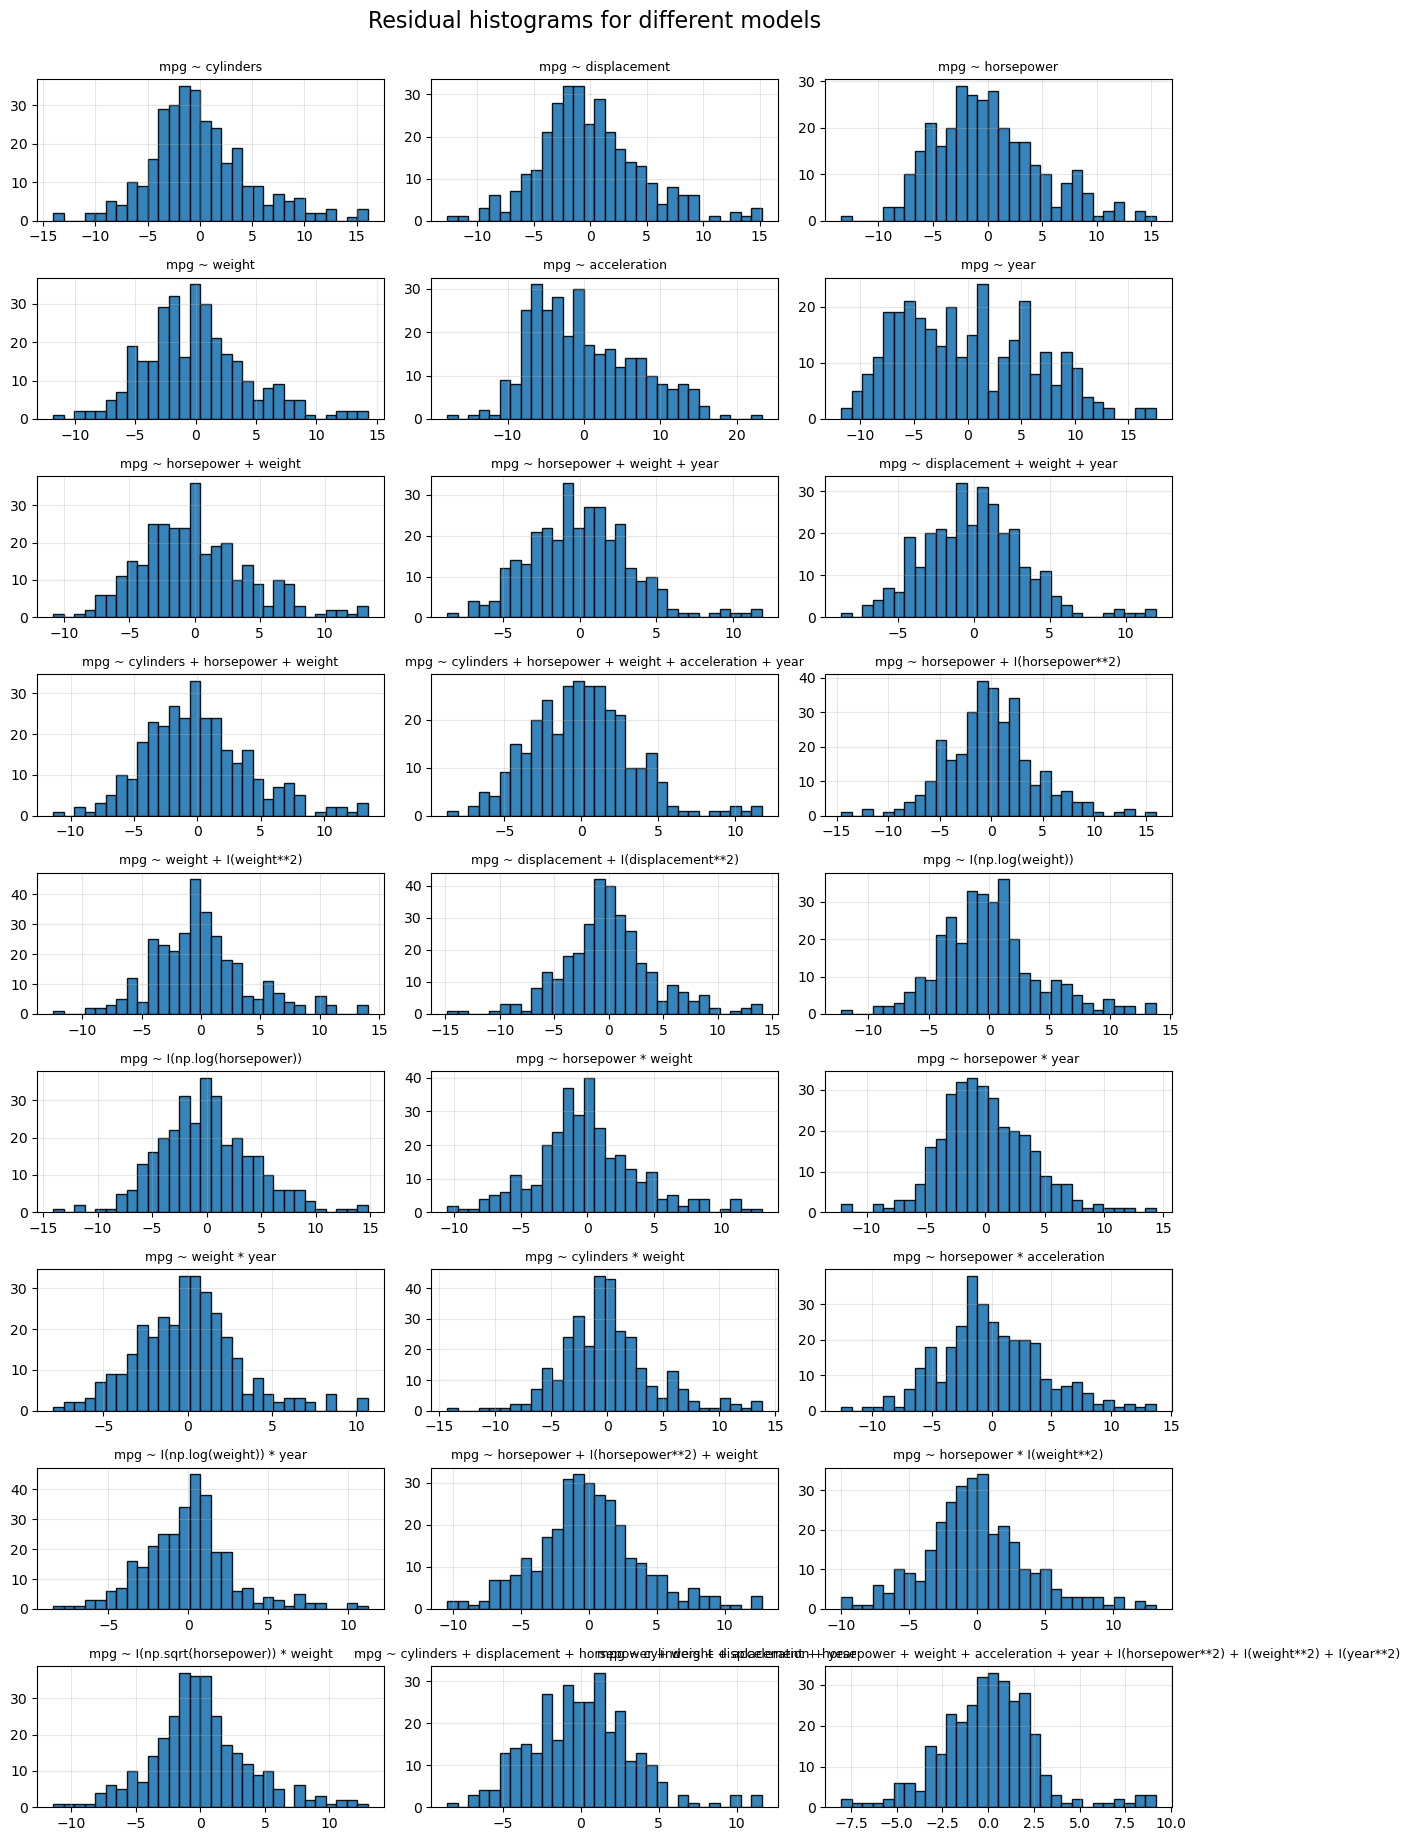

In [166]:
fig, axes = plt.subplots(9, 3, figsize=(12, 18))
axes = axes.flatten()

for i, formula in enumerate(models):
    ax = axes[i]
    ax.hist(results[i].resid, bins=30, edgecolor="black", alpha=0.9)
    
    ax.set_title(formula, fontsize=9)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.suptitle("Residual histograms for different models", fontsize=16, y=1.02)
plt.show()


Wybór najlepszego modelu

In [167]:
best_formula = min_model[0]
best_result = results[models.index(best_formula)]

Diagnostyka modelu

In [ ]:
influence = best_result.get_influence()
stud_resid = influence.resid_studentized_external
hat_values = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

diagn = pd.DataFrame({
    "stud_resid": stud_resid,
    "hat": hat_values,
    "cooks_d": cooks_d
}, index=train.index)

# progi
p = best_result.df_model
n = best_result.nobs

lev_thr = 2 * (p + 1) / n
cook_thr = 4 / (n - p - 1)

outliers = set(diagn[abs(diagn["stud_resid"]) > 3].index)
high_lev = set(diagn[diagn["hat"] > lev_thr].index)
cook_outliers = set(diagn[diagn["cooks_d"] > cook_thr].index)

to_remove = outliers | cook_outliers# | high_lev

print("Worst formula:", best_result.summary())
print("Removed observation:", len(to_remove))

Worst formula:                             OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     247.2
Date:                Thu, 20 Nov 2025   Prob (F-statistic):          6.56e-134
Time:                        17:17:56   Log-Likelihood:                -750.07
No. Observations:                 313   AIC:                             1520.
Df Residuals:                     303   BIC:                             1558.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            

Usunięcie punktów odstających

In [183]:
clean_train = train.drop(index=to_remove)

clean_result = sm.OLS(
    *dmatrices(best_formula, data=clean_train, return_type='dataframe')
).fit()

clean_rmse = compute_rmse(clean_result, valid, formula=best_formula)

print("RMSE przed czyszczeniem:", min(rmse_list))
print("RMSE po czyszczeniu:", clean_rmse)

RMSE przed czyszczeniem: 3.294871808992498
RMSE po czyszczeniu: 3.3466908792759464


Wykres do prezentacji danych

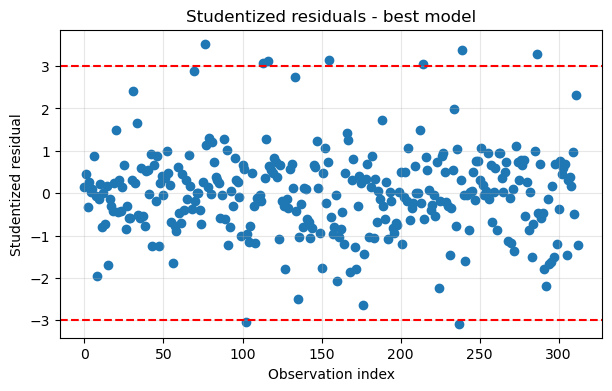

In [184]:
plt.figure(figsize=(7, 4))
plt.scatter(range(len(stud_resid)), stud_resid)
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.title("Studentized residuals - best model")
plt.xlabel("Observation index")
plt.ylabel("Studentized residual")
plt.grid(alpha=0.3)
plt.show()